In [3]:
import pandas as pd
import numpy as np
import os
import sys
from numpy.random import default_rng
import re
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.api import OLS
import statsmodels.api as sm
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
import itertools
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.feature_selection import RFE
import warnings

In [4]:
df = pd.read_csv('Raw Data.csv')
y = pd.read_csv('Target Data.csv')

In [5]:
feature_with_missing_values = df.columns[df.isna().any()]
feature_with_missing_values, len(feature_with_missing_values)

(Index(['county', 'community', 'OtherPerCap', 'LemasSwornFT', 'LemasSwFTPerPop',
        'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop', 'LemasTotalReq',
        'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop',
        'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp',
        'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits',
        'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'PolicCars', 'PolicOperBudg',
        'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'PolicBudgPerPop'],
       dtype='object'),
 25)

In [6]:
## Caculate missing rate for each feature:
missing_rate = df[feature_with_missing_values].isna().mean() * 100
missing_rate.rename('missing_rate', inplace=True)
missing_rate.head()

county             58.876630
community          59.027081
OtherPerCap         0.050150
LemasSwornFT       84.002006
LemasSwFTPerPop    84.002006
Name: missing_rate, dtype: float64

In [7]:
missing_rate_df = pd.DataFrame(missing_rate)
missing_rate_df.reset_index(inplace=True)
missing_rate_df.head()

,index,missing_rate
0,county,58.876630
1,community,59.027081
2,OtherPerCap,0.050150
3,LemasSwornFT,84.002006
4,LemasSwFTPerPop,84.002006


In [8]:
## Visualizing missing rate

<Axes: xlabel='missing_rate', ylabel='index'>

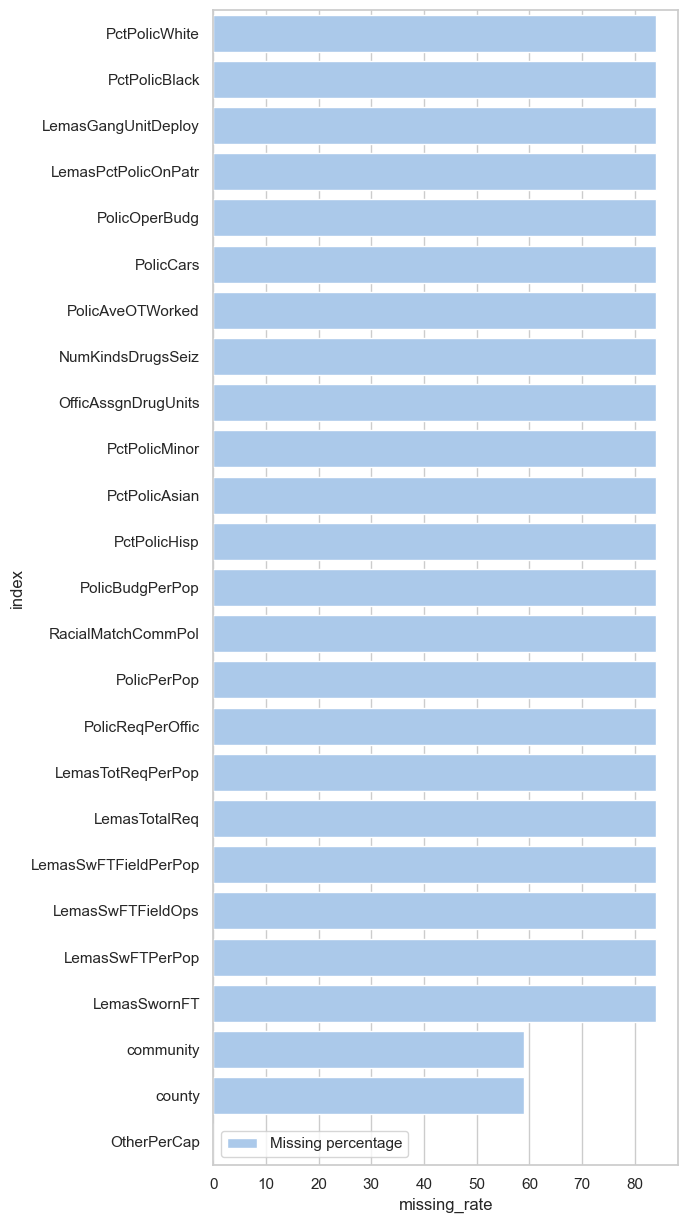

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 15))

# Load the example car crash dataset
crashes = missing_rate_df.sort_values(by = 'missing_rate', ascending=False)

# Plot the total crashes
sns.set_color_codes("pastel")
sns.barplot(x="missing_rate", y = 'index', data=crashes,
            label="Missing percentage", color="b")


In [10]:
high_missing_rate_features = missing_rate_df[missing_rate_df['missing_rate'] > 50]['index'].tolist()

In [11]:
good_features = [col for col in df.columns if col not in high_missing_rate_features]
len(good_features)

103

In [12]:
df_clear = df[good_features]

In [13]:
df_clear = df_clear.drop('communityname', axis = 1)

In [14]:
df_clear.fillna(0, inplace = True)
df_clear.isna().sum().sum()

0

In [15]:
df_clear.head()

,state,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn
0,8,1,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,...,0.0,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32
1,53,1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,...,0.0,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00
2,24,1,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,...,0.0,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00
3,34,1,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,...,0.0,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00
4,42,1,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,...,0.0,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00


In [280]:
X = df_clear.to_numpy()
Y = y.to_numpy()

## ML Modeling Process
#### a(i) What are the most important features?
* Step1. Split Data

In [192]:
# Standardize X (centered and scaled)
scaler = StandardScaler(with_mean = True, with_std = True)
X_standardized = scaler.fit_transform(X)

In [193]:
Y_centered = y - np.mean(y)

# Step 2. Select Features
## Method1. Least Squares via OLS

In [194]:
X_train_with_intercept = sm.add_constant(X)
# Run OLS regression
model = sm.OLS(y, X).fit()

# Check p-values
p_values = model.pvalues[1:]  # Exclude the intercept term
significant_features = np.where(p_values < 0.05)[0]  # Select features with p-value < 0.05
significant_features, len(significant_features)

(array([ 3, 12, 15, 22, 26, 29, 34, 35, 39, 40, 49, 51, 65, 67, 68, 69, 70,
        72, 75, 76, 80, 83, 86, 89, 90, 91]),
 26)

In [195]:
significant_features_by_OLS = df_clear.columns[significant_features]
significant_features_by_OLS

Index(['householdsize', 'numbUrban', 'pctWWage', 'perCapInc', 'AsianPerCap',
       'NumUnderPov', 'PctUnemployed', 'PctEmploy', 'PctOccupMgmtProf',
       'MalePctDivorce', 'PctWorkMomYoungKids', 'NumIlleg',
       'PctLargHouseOccup', 'PersPerOwnOccHous', 'PersPerRentOccHous',
       'PctPersOwnOccup', 'PctPersDenseHous', 'MedNumBR', 'PctHousOwnOcc',
       'PctVacantBoarded', 'PctWOFullPlumb', 'OwnOccHiQuart', 'RentHighQ',
       'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'NumInShelters'],
      dtype='object')

## Method2. Best Subset Selection

In [ ]:
# Define a linear regression model
linear_reg = LinearRegression()

#Obtain exhaustive mse values
efs = EFS(
    linear_reg,
    min_features = 1,
    max_features = 3,
    scoring = "neg_mean_squared_error", #we use negative mse since the sfs method maximizes the score
    cv = 0
)
efs.fit(X_standardized, Y_centered)

#Obtain a summary of the exhaustive results (all possible models)
efs_summary = pd.DataFrame.from_dict(efs.get_metric_dict()).T[["feature_idx", "avg_score"]]
efs_summary["feature_idx"]
efs_size = np.zeros(len(efs_summary))
for i in range(len(efs_summary)):
    efs_size[i] = len(efs_summary["feature_idx"][i])
efs_summary['model size'] = efs_size
efs_summary.rename(columns={'avg_score': 'neg_mse'}, inplace=True)
print("The first few results for exhaustive feature selection (all possible models) look like:")
print(efs_summary.iloc[range(15)].to_string(index=False))

## Method3. Step-wise approache

In [197]:
def calculate_aic(estimator, X, y):
    """
    Custom AIC scorer for SequentialFeatureSelector.
    Args:
        estimator: A fitted sklearn-compatible estimator.
        X: Features (numpy array).
        y: Target variable (numpy array).
    Returns:
        Negative AIC value for compatibility with SFS (higher is better).
    """
    n, k = X.shape  # n: number of samples, k: number of predictors
    y_pred = estimator.predict(X)
    residual_sum_of_squares = np.sum((y - y_pred) ** 2)
    aic = n * np.log(residual_sum_of_squares / n) + 2 * k
    return -aic  # SFS maximizes the score

def aic_scorer_wrapper(estimator, X, y):
    estimator.fit(X, y)
    return calculate_aic(estimator, X, y)

In [198]:
model = LinearRegression()
sfs_forward = SFS(
    model,
    k_features = 'best',
    forward = True,
    floating = False,
    scoring = aic_scorer_wrapper,  # Use custom AIC scorer
    cv = 0  # No cross-validation, evaluate on the whole dataset
)

sfs_forward.fit(X_standardized,Y_centered)
significant_features_by_step_wise = np.array(colnames)[np.array(sfs_forward.k_feature_names_, dtype=int)]
print("Selected features:", np.array(colnames)[np.array(sfs_forward.k_feature_names_, dtype=int)])
print('Lenth of selected features:', len(np.array(colnames)[np.array(sfs_forward.k_feature_names_, dtype=int)]))
print(pd.DataFrame.from_dict(sfs_forward.get_metric_dict()).T[["feature_idx", "avg_score"]])

Selected features: ['state' 'fold' 'racepctblack' 'racePctWhite' 'racePctHisp' 'agePct12t29'
 'agePct65up' 'numbUrban' 'pctUrban' 'pctWWage' 'pctWFarmSelf'
 'pctWInvInc' 'pctWRetire' 'medFamInc' 'perCapInc' 'whitePerCap'
 'blackPerCap' 'indianPerCap' 'AsianPerCap' 'OtherPerCap' 'PctPopUnderPov'
 'PctLess9thGrade' 'PctBSorMore' 'PctEmploy' 'PctEmplManu' 'PctOccupManu'
 'MalePctDivorce' 'MalePctNevMarr' 'TotalPctDiv' 'PctKids2Par'
 'PctWorkMom' 'PctIlleg' 'NumImmig' 'PctNotSpeakEnglWell'
 'PctLargHouseOccup' 'PersPerOccupHous' 'PersPerRentOccHous'
 'PctPersOwnOccup' 'PctPersDenseHous' 'HousVacant' 'PctHousOccup'
 'PctHousOwnOcc' 'PctVacantBoarded' 'PctVacMore6Mos' 'OwnOccLowQuart'
 'OwnOccMedVal' 'RentLowQ' 'MedRent' 'MedRentPctHousInc'
 'MedOwnCostPctInc' 'MedOwnCostPctIncNoMtg' 'NumInShelters' 'NumStreet'
 'PctForeignBorn' 'PctSameCity85' 'PctUsePubTrans' 'LemasPctOfficDrugUn']
Lenth of selected features: 57
                                           feature_idx    avg_score
1         

## Method4. Lasso

In [199]:
lasso = LassoCV(cv = 5).fit(X_standardized,Y_centered)
significant_features_by_lasso = df_clear.columns[np.where(lasso.coef_ != 0)[0]]
significant_features_by_lasso, len(significant_features_by_lasso)

(Index(['state', 'fold', 'householdsize', 'racepctblack', 'racePctWhite',
        'racePctHisp', 'agePct12t21', 'agePct12t29', 'agePct65up', 'numbUrban',
        'pctUrban', 'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec',
        'pctWRetire', 'medFamInc', 'whitePerCap', 'blackPerCap', 'indianPerCap',
        'AsianPerCap', 'OtherPerCap', 'HispPerCap', 'PctPopUnderPov',
        'PctLess9thGrade', 'PctBSorMore', 'PctUnemployed', 'PctEmploy',
        'PctEmplManu', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce',
        'MalePctNevMarr', 'FemalePctDiv', 'PctKids2Par', 'PctYoungKids2Par',
        'PctWorkMomYoungKids', 'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig',
        'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8', 'PctRecImmig8',
        'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup',
        'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous',
        'PctPersOwnOccup', 'PctPersDenseHous', 'PctHousLess3BR', 'MedNumBR',
        'HousVacant

## Method5. Elastic Net

In [200]:
elastic_net = ElasticNetCV(l1_ratio = 0.5, cv = 5).fit(X_standardized,Y_centered)
significant_features_by_elastic_net = df_clear.columns[np.where(elastic_net.coef_ != 0)[0]]
significant_features_by_elastic_net, len(significant_features_by_elastic_net)

(Index(['state', 'fold', 'householdsize', 'racepctblack', 'racePctWhite',
        'racePctHisp', 'agePct12t21', 'agePct12t29', 'agePct65up', 'numbUrban',
        'pctUrban', 'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec',
        'pctWRetire', 'medFamInc', 'whitePerCap', 'blackPerCap', 'indianPerCap',
        'AsianPerCap', 'OtherPerCap', 'HispPerCap', 'PctPopUnderPov',
        'PctLess9thGrade', 'PctBSorMore', 'PctUnemployed', 'PctEmploy',
        'PctEmplManu', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce',
        'MalePctNevMarr', 'FemalePctDiv', 'PctKids2Par', 'PctYoungKids2Par',
        'PctWorkMomYoungKids', 'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig',
        'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8', 'PctRecImmig8',
        'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup',
        'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous',
        'PctPersOwnOccup', 'PctPersDenseHous', 'PctHousLess3BR', 'MedNumBR',
        'HousVacant

* a(ii) Fit and visualize regularization paths for the following methods
* Lasso coefficients path

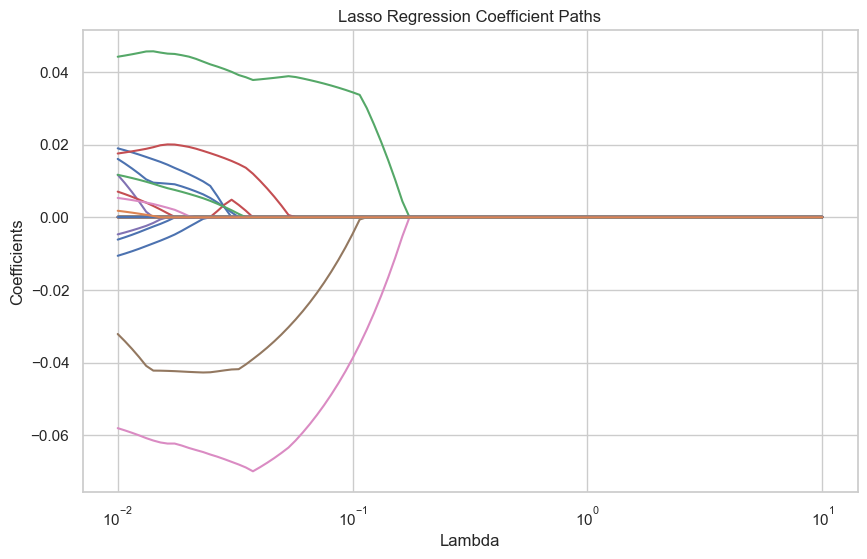

In [282]:
lambdas = np.exp(np.linspace(np.log(0.01), np.log(10), 100))
betasl = np.zeros((len(lambdas), X.shape[1]))
for i, lamb in enumerate(lambdas):
    lasso = Lasso(alpha = lamb)
    lasso.fit(X_standardized,Y_centered)
    betasl[i, :] = lasso.coef_

# Plot Lasso paths (log-scale)
plt.figure(figsize=(10, 6))
for j in range(X_train.shape[1]): #for each variable
    plt.plot(lambdas, betasl[:, j], label=f"Variable {j+1}")
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Coefficients")
plt.title("Lasso Regression Coefficient Paths")
#plt.legend(colnames)
plt.show()

* Elastic Net coefficients path

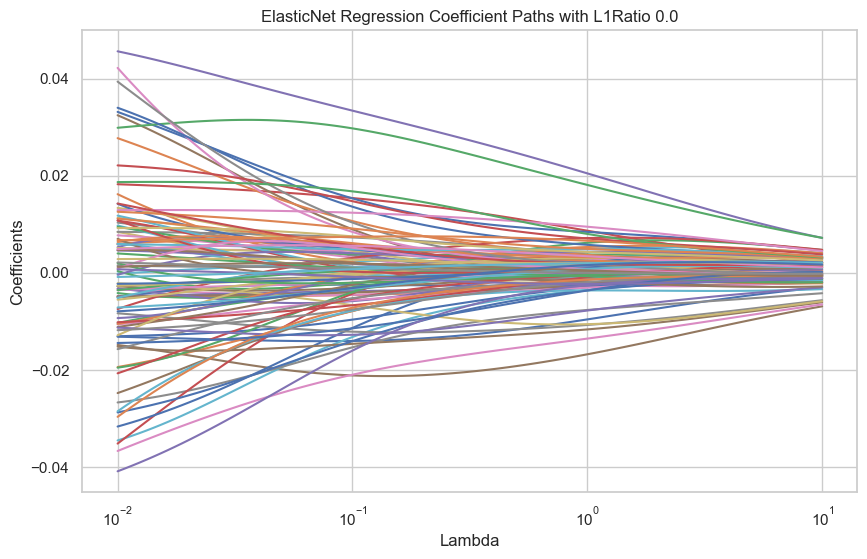

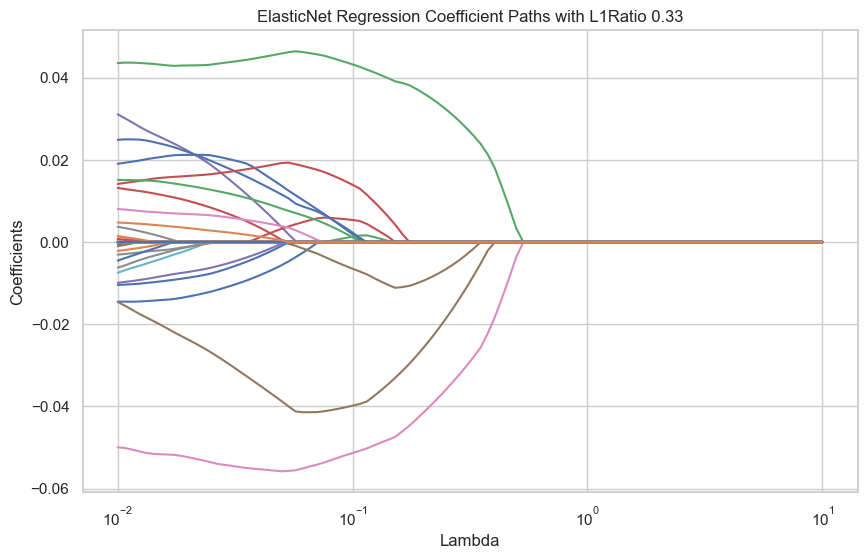

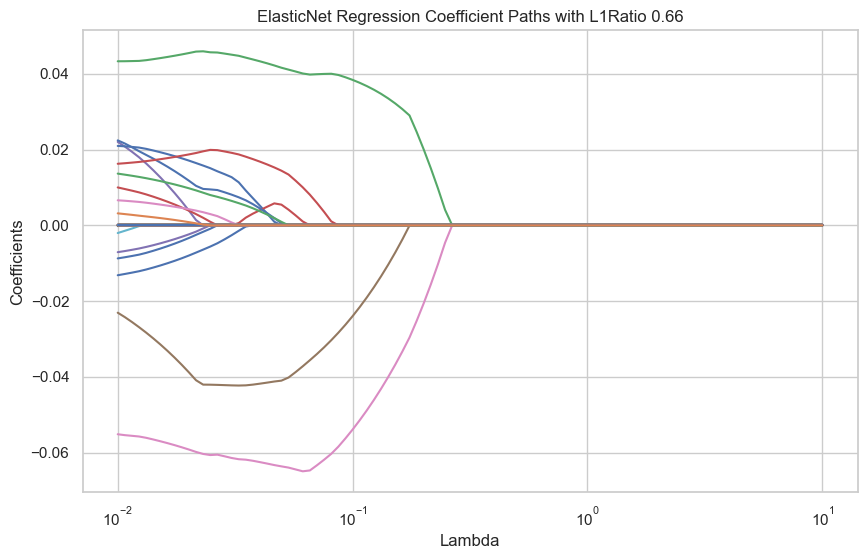

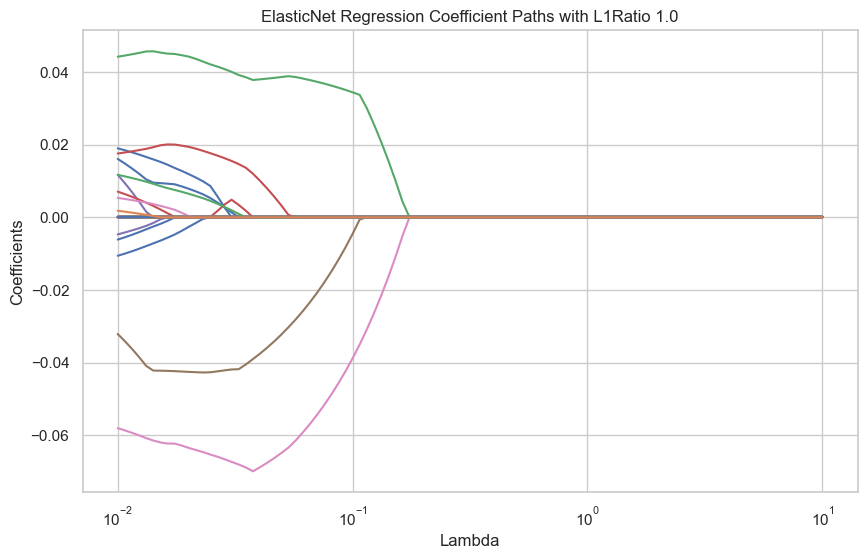

In [283]:
warnings.filterwarnings("ignore")

lambdas = np.exp(np.linspace(np.log(0.01), np.log(10), 100))
l1ratios = np.array([0, 0.33, 0.66, 1])
coefs = pd.DataFrame()
for l1ratio in l1ratios:
    betase = np.zeros((len(lambdas), X.shape[1]))
    for i, lamb in enumerate(lambdas):
        elasticnet = ElasticNet(alpha=lamb, l1_ratio = l1ratio, fit_intercept=False)
        elasticnet.fit(X_standardized,Y_centered)
        betase[i, :] = elasticnet.coef_

    # Plot Lasso paths (log-scale)
    plt.figure(figsize=(10, 6))
    for j in range(X_train.shape[1]): #for each variable
        plt.plot(lambdas, betase[:, j], label=f"Variable {j+1}")
    plt.xscale("log")
    plt.xlabel("Lambda")
    plt.ylabel("Coefficients")
    plt.title("ElasticNet Regression Coefficient Paths with L1Ratio " + str(l1ratio))
    #plt.legend(colnames)
    plt.show()
    elasticnet = ElasticNet(alpha=1, l1_ratio = l1ratio, fit_intercept=False)
    elasticnet.fit(X_standardized,Y_centered)
    coefs[l1ratio] = elasticnet.coef_

In [207]:
significant_features_by_diff_methods = {'OLS': len(significant_features_by_OLS),
                                       'Step_wise': len(significant_features_by_step_wise),
                                       'Lasso': len(significant_features_by_lasso),
                                       'Elastic Net': len(significant_features_by_elastic_net)}

In [208]:
features_df = pd.DataFrame(list(significant_features_by_diff_methods.items()), columns = ['Features', 'Feature number'])

In [209]:
features_df

,Features,Feature number
0,OLS,26
1,Step_wise,57
2,Lasso,76
3,Elastic Net,76


In [210]:
set1 = set(significant_features_by_OLS)
set2 = set(significant_features_by_step_wise)
set3 = set(significant_features_by_lasso)
set4 = set(significant_features_by_elastic_net)

common_elements = set1 & set2 & set3 & set4

print(common_elements)

{'MedOwnCostPctIncNoMtg', 'PctLargHouseOccup', 'PctEmploy', 'PctPersDenseHous', 'AsianPerCap', 'pctWWage', 'PctVacantBoarded', 'PctPersOwnOccup', 'MalePctDivorce', 'MedOwnCostPctInc', 'NumInShelters', 'PersPerRentOccHous', 'numbUrban'}


* a(iii) Reflect on these results. Are the top features different for each method? Why or why not? If there are tuning parameters, how did you determine these? Do different tuning parameters yield different important features? Are there any features consistently selected by all methods? What are the most important features and how did you determine this? Explain and expand on your responses.

* Answer:

    I was unable to compute the optimal feature subset determined by the best subset selection method, possibly due to computational limitations. I attempted to apply the best subset selection method using several approaches, but the program ran for an extended period without producing results. I believe this is because the dataset contains 102 features, leading to an excessive number of feature subset combinations. The best subset selection method requires iterating over all possible subsets, which results in an infeasibly long computation time. Therefore, I first discuss the results of the other four feature selection algorithms.

    First, we observe that the number of selected features differs across algorithms. Among them, the least squares method selects the smallest number of features. The differences in the selected feature subsets arise from the distinct principles each method employs to determine important features:

    Least Squares Regression selects features based on statistical significance, measured by p-values. The p-value of a feature indicates the strength of its relationship with the target variable. A large p-value suggests a weak relationship, making the feature a candidate for removal.

    Stepwise Regression is a greedy algorithm that sequentially selects or removes features based on criteria such as p-values, Akaike Information Criterion (AIC), or Bayesian Information Criterion (BIC).

    Lasso Regression is a linear regression method with L1 regularization. It introduces an L1 penalty term in the loss function, which encourages sparsity by shrinking some regression coefficients to zero, thereby performing feature selection.

    Elastic Net combines the characteristics of Lasso and Ridge regression by incorporating a weighted sum of L1 and L2 penalties.

    Due to these different selection criteria, the optimal feature subsets identified by different methods are not identical.

    Regarding parameter tuning, I split the dataset into two parts: training data and test data. For tuning the regularization parameter 𝜆 in the Lasso method, I used k-fold cross-validation to select the optimal 𝜆. The choice of 𝜆 influences the final selected subset because Lasso applies L1 regularization to shrink certain regression coefficients to zero, effectively performing feature selection. Different values of 𝜆 control the strength of regularization, thereby determining which features are retained or removed.

    Some features were selected by all algorithms, including: ’pctUrban’, ’PctWorkMom’, ’RentLowQ’, ’pctWInvInc’, ’PctIlleg’, ’HousVacant’, ’PctPersOwnOccup’, ’NumStreet’, ’MalePctNevMarr’, ’NumInShelters’, ’state’, ’PctVacMore6Mos’, ’racepctblack’, ’OtherPerCap’, ’pctWRetire’, ’agePct12t29’. Additionally, based on the coefficient path in Lasso regression, certain features such as 'NumStreet', 'NumInShelters', and 'pctWInvInc' are particularly important. In Lasso models, the coefficient path reveals the dependency of the model on each feature. Features whose coefficients decrease more slowly tend to have larger coefficients in the absence of strong regularization, indicating their significant contribution to the model.



#### b(i) Compare the average prediction MSE on the test set for the following methods:

In [215]:
# Set a random seed for reproducibility
rng = default_rng(1)

# Define the proportions for the split
train_prop = 0.6
validation_prop = 0.2
test_prop = 0.2

# Calculate the number of observations for each split
total_samples = df_clear.shape[0]
train_size = int(train_prop * total_samples)
validation_size = int(validation_prop * total_samples)
test_size = total_samples - train_size - validation_size

# Create a random permutation of row indices
indices = rng.choice(np.arange(total_samples), size=(total_samples), replace=False)

# Split the dataset into train, validation, and test sets
y_train = Y[indices[:train_size]]
y_val = Y[indices[(train_size + 1):(train_size + validation_size)]]
y_test = Y[indices[(train_size + validation_size + 1):]]

X_train = X_standardized[indices[:train_size]]
X_val = X_standardized[indices[(train_size + 1):(train_size + validation_size)]]
X_test = X_standardized[indices[(train_size + validation_size + 1):]]

In [216]:
#Hyperparameter Validation for the Lasso
# Create a sequence of alpha values to try
alpha_seq = 10 ** np.linspace(-2, 0.5, num=100)

# Create empty dictionary to store the results
results = {'alpha': [], 'mse_train': [], 'mse_val': [], 'mse_test': []}

for i, alpha in enumerate(alpha_seq):
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)

    y_train_pred = lasso.predict(X_train)
    y_val_pred = lasso.predict(X_val)
    y_test_pred = lasso.predict(X_test)

    results['alpha'].append(alpha)
    results['mse_train'].append(np.mean((y_train_pred - y_train) ** 2))
    results['mse_val'].append(np.mean((y_val_pred - y_val) ** 2))
    results['mse_test'].append(np.mean((y_test_pred - y_test) ** 2))

Best alpha: 0.173


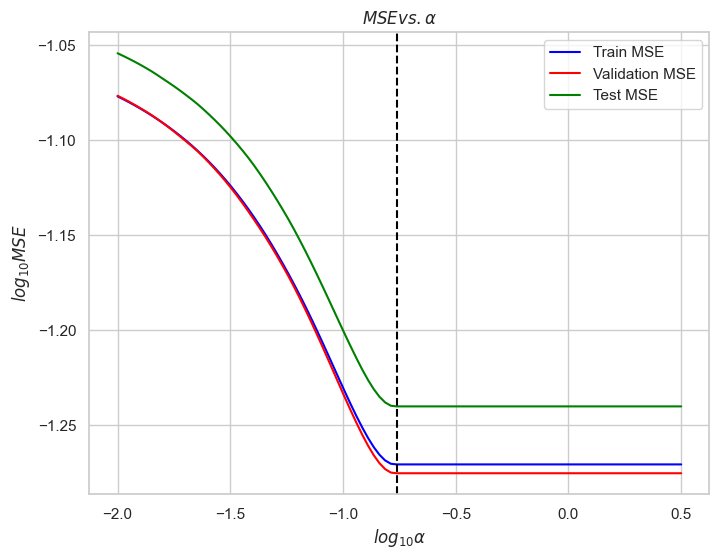

In [217]:
# Select the alpha value that minimizes the validation MSE
best_alpha = results['alpha'][np.argmin(results['mse_val'])]
print(f'Best alpha: {best_alpha:.3f}')

plt.figure(figsize=(8, 6))
plt.plot(np.log10(results['alpha']), np.log10(results['mse_train']), linestyle='-', color='blue', label='Train MSE')
plt.plot(np.log10(results['alpha']), np.log10(results['mse_val']), linestyle='-', color='red', label='Validation MSE')
plt.plot(np.log10(results['alpha']), np.log10(results['mse_test']), linestyle='-', color='green', label='Test MSE')
plt.axvline(np.log10(best_alpha), linestyle='dashed', color='black')

plt.xlabel('$log_{10} \\alpha$')
plt.ylabel('$log_{10} MSE$')
plt.title('$MSE vs. \\alpha$')
plt.legend(loc='upper right')

plt.show()

{'Least Squares': [0.019882679052861243, 0.019882679052861243, 0.019882679052861243, 0.019882679052861243, 0.019882679052861243, 0.019882679052861243, 0.019882679052861243, 0.019882679052861243, 0.019882679052861243, 0.019882679052861243], 'Ridge': [0.019259685046270715, 0.019259685046270715, 0.019259685046270715, 0.019259685046270715, 0.019259685046270715, 0.019259685046270715, 0.019259685046270715, 0.019259685046270715, 0.019259685046270715, 0.019259685046270715], 'Lasso': [0.01937623427677032, 0.01937623427677032, 0.01937623427677032, 0.01937623427677032, 0.01937623427677032, 0.01937623427677032, 0.01937623427677032, 0.01937623427677032, 0.01937623427677032, 0.01937623427677032], 'Elastic Net': [0.019374828887604566, 0.019374828887604566, 0.019374828887604566, 0.019374828887604566, 0.019374828887604566, 0.019374828887604566, 0.019374828887604566, 0.019374828887604566, 0.019374828887604566, 0.019374828887604566], 'Stepwise RFE': [0.02484116342668184, 0.02484116342668184, 0.0248411634

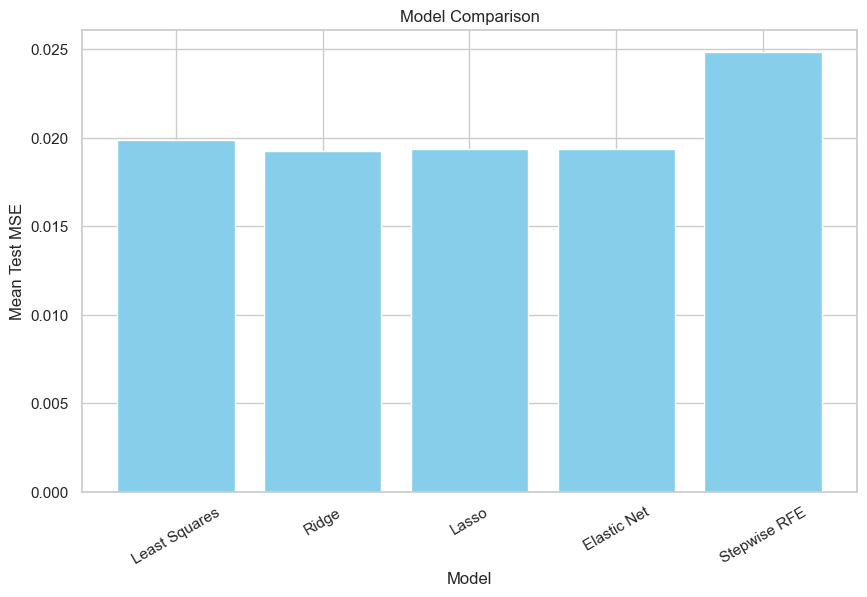

0.020546918138037735


In [288]:
def evaluate_models(X_train, y_train, X_test, y_test, n_splits=10):
    results = {"Least Squares": [], "Ridge": [], "Lasso": [], "Elastic Net": [], "Stepwise RFE": []}
    
    for _ in range(n_splits):
        
        # Least Squares
        ls_model = LinearRegression().fit(X_train, y_train)
        results["Least Squares"].append(mean_squared_error(y_test, ls_model.predict(X_test)))
        
        # Ridge Regression
        ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 10), store_cv_values=True).fit(X_train, y_train)
        results["Ridge"].append(mean_squared_error(y_test, ridge_model.predict(X_test)))
        
        # Lasso Regression
        lasso_model = LassoCV(alphas=np.logspace(-3, 3, 10), cv=5).fit(X_train, y_train)
        results["Lasso"].append(mean_squared_error(y_test, lasso_model.predict(X_test)))
        
        # Elastic Net
        elastic_net_model = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=np.logspace(-3, 3, 10), cv=5).fit(X_train, y_train)
        results["Elastic Net"].append(mean_squared_error(y_test, elastic_net_model.predict(X_test)))
        
        
        # Stepwise (RFE)
        rfe = RFE(LinearRegression(), n_features_to_select=5).fit(X_train, y_train)
        stepwise_model = LinearRegression().fit(X_train[:, rfe.support_], y_train)
        results["Stepwise RFE"].append(mean_squared_error(y_test, stepwise_model.predict(X_test[:, rfe.support_])))
    
    return results

# 运行评估
results = evaluate_models(X_train, y_train, X_test, y_test)

print(results)

final_results = {key: sum(value) / len(value) for key, value in results.items()}

# 可视化结果
plt.figure(figsize=(10, 6))
mse_means = mse_df['MSE']
plt.bar(mse_df.Method, mse_means.values, color='skyblue')
plt.ylabel("Mean Test MSE")
plt.xlabel("Model")
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()

# 打印平均MSE
print(mse_df.MSE.mean())